# Run an original or retrained Chronos model and measure probing space saving

**Run all in Colab. No input table or repository checkout is needed.** Select `MODEL_SOURCE = "retrained"` (default) or `"published"` for the original
`amazon/chronos-bolt-tiny`. The original requires `P, S = 16, 16`; retrained checkpoints use
the selected `P` and `S` (default: `p16-s16-seed42`). The notebook downloads that checkpoint, generates pure
sinusoids, makes real forecasts while capturing decoder states, runs MDL on seven frequency-band
tasks, and saves a space-saving figure and its newly computed values.

Use a Colab GPU for model inference. The linear MDL probes run on CPU. `SMOKE = True` makes a small
run with the **same real checkpoint**, stored and labelled separately; it is only a runtime check.
With `SAVE_TO_DRIVE = True`, outputs are written to Drive. No model is trained or retrained here.

Both sources use the same generated inputs, seeds, probe stages, and MDL procedure.
Output folders, figure labels, and provenance distinguish original and retrained weights.
Changing the source changes only the checkpoint; it does not reproduce the paper's estimator. The figure follows
[Pagani et al., Figure 3](https://arxiv.org/html/2605.06361v1), but the estimator is the repository's
five-chunk prequential MDL with scaling, PCA(20), and logistic regression, rather than the paper's
replay-based online estimator. The uniformly encoded first chunk gives an SV ceiling near 0.8.
Each control permutes the same task's labels on the same features, with identical coding chunks.


In [1]:
# Standalone dependencies: no imports from the patchAliasing checkout.
import importlib.util
import subprocess
import sys
packages = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
            "sklearn": "scikit-learn", "torch": "torch", "huggingface_hub": "huggingface-hub",
            "accelerate": "accelerate", "chronos": "chronos-forecasting", "tqdm": "tqdm"}
missing = []
for module, package in packages.items():
    spec = importlib.util.find_spec(module)
    if spec is None or (module == "chronos" and spec.origin is None):
        missing.append(package)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    importlib.invalidate_caches()
    # A local folder named chronos may have been imported as a namespace before installation.
    if "chronos" in sys.modules and not getattr(sys.modules["chronos"], "__file__", None):
        del sys.modules["chronos"]

from pathlib import Path
from datetime import datetime, timezone
from math import gcd
import hashlib
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from huggingface_hub import snapshot_download
from chronos import BaseChronosPipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from threadpoolctl import threadpool_limits
from tqdm.auto import tqdm
from IPython.display import Image, display


In [2]:
# ---- choose the checkpoint and experiment ---------------------------------------
MODEL_SOURCE = "published"  # "retrained" or "published" (original Amazon model)
P, S = 16, 16
LOCAL_MODEL_DIR = None  # Optional finished checkpoint directory; otherwise download from HF.
PUBLISHED_ID = "amazon/chronos-bolt-tiny"
PUBLISHED_REVISION = "a0e552de83495b5c28c14c71c374f3e33280b340"
SWEEP_REPO = "federicosabbadini/chronos-bolt-patch-sweep"
SWEEP_REVISION = "230ea28278a3c60621964b920e9778c0ba73337e"  # same immutable revision as model_loader.py

SEED = 42
FS = 512
CONTEXT_LENGTH = 512
FREQUENCY_STEP = 1           # Hz, over [2, 250]
MAX_PHASE_SHIFTS = 32       # capped separately by fs/gcd(f,fs)-1 for each frequency
BATCH_SIZE = 64
MDL_CHUNKS = 5
PCA_COMPONENTS = 20
CPU_THREADS = 2             # limits BLAS oversubscription during the small linear fits
SMOKE = False
SAVE_TO_DRIVE = True
OUTPUT_ROOT = None          # Optional output folder. No existing data are required.

BAND_TASKS = [("LL", 2, 64, 33), ("L", 2, 126, 64), ("LH", 65, 126, 95),
              ("Mid", 2, 250, 126), ("HL", 127, 188, 157),
              ("H", 127, 250, 188), ("HH", 189, 250, 219)]
TASK_ORDER = [task[0] for task in BAND_TASKS]
if MODEL_SOURCE not in {"retrained", "published"}:
    raise ValueError('MODEL_SOURCE must be "retrained" or "published".')
if MODEL_SOURCE == "published" and (P, S) != (16, 16):
    raise ValueError("The original Chronos-Bolt-Tiny has P=S=16; set P, S = 16, 16.")
if MODEL_SOURCE == "published" and LOCAL_MODEL_DIR is not None:
    raise ValueError("LOCAL_MODEL_DIR applies only to retrained checkpoints; set it to None for published.")
MODEL_LABEL = "original Amazon" if MODEL_SOURCE == "published" else "retrained"
GEOMETRY = f"p{P}-s{S}"
if not (isinstance(P, int) and isinstance(S, int) and 0 < S <= P):
    raise ValueError("Require integer patch/stride with 0 < S <= P.")
for name in ("CONTEXT_LENGTH", "FREQUENCY_STEP", "MAX_PHASE_SHIFTS", "BATCH_SIZE", "PCA_COMPONENTS", "CPU_THREADS"):
    if not isinstance(globals()[name], int) or globals()[name] < 1:
        raise ValueError(f"{name} must be a positive integer.")
if not isinstance(MDL_CHUNKS, int) or MDL_CHUNKS < 2:
    raise ValueError("MDL_CHUNKS must be an integer >= 2.")
if SMOKE:
    FREQUENCY_STEP, MAX_PHASE_SHIFTS = 16, 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cpu":
    torch.set_num_threads(CPU_THREADS)

def in_colab():
    try:
        return importlib.util.find_spec("google.colab") is not None
    except ModuleNotFoundError:
        return False

if OUTPUT_ROOT is None and SAVE_TO_DRIVE and in_colab():
    from google.colab import drive
    if not Path("/content/drive/MyDrive").is_dir():
        drive.mount("/content/drive")
    base = Path("/content/drive/MyDrive/patchAliasing/probing_space_saving")
else:
    base = Path(OUTPUT_ROOT).expanduser() if OUTPUT_ROOT else Path.cwd() / "_run" / "probing_space_saving"
RUN_KIND = "SMOKE" if SMOKE else "FULL"
OUT = base / RUN_KIND.lower() / f"{MODEL_SOURCE}_{GEOMETRY}_{datetime.now(timezone.utc):%Y%m%dT%H%M%S%fZ}"
(OUT / "figures").mkdir(parents=True, exist_ok=True)
print(f"{RUN_KIND}: {MODEL_LABEL} {GEOMETRY}, device={DEVICE}; output: {OUT}")


FULL: original Amazon p16-s16, device=cpu; output: c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260907T225513660729Z


## 1. Load and verify the selected checkpoint


In [3]:
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def load_model():
    subfolder = f"p{P}-s{S}-seed42"
    if MODEL_SOURCE == "published":
        model_dir = Path(snapshot_download(PUBLISHED_ID, revision=PUBLISHED_REVISION,
                                           allow_patterns=["config.json", "model.safetensors"]))
        identity = {"source": "huggingface", "repo": PUBLISHED_ID, "revision": PUBLISHED_REVISION}
    elif LOCAL_MODEL_DIR is not None:
        model_dir = Path(LOCAL_MODEL_DIR).expanduser().resolve()
        identity = {"source": "local", "path": str(model_dir)}
    else:
        snapshot = snapshot_download(SWEEP_REPO, revision=SWEEP_REVISION,
                                     allow_patterns=[f"{subfolder}/*"])
        model_dir = Path(snapshot) / subfolder
        identity = {"source": "huggingface", "repo": SWEEP_REPO,
                    "revision": SWEEP_REVISION, "subfolder": subfolder}
    required = ["config.json", "model.safetensors"]
    if MODEL_SOURCE == "retrained":
        required.append("run_config.json")
    identity["model_source"] = MODEL_SOURCE
    absent = [name for name in required if not (model_dir / name).is_file()]
    if absent:
        raise FileNotFoundError(f"Incomplete selected checkpoint at {model_dir}: missing {absent}")
    config = json.loads((model_dir / "config.json").read_text())
    run_config = (json.loads((model_dir / "run_config.json").read_text())
                  if MODEL_SOURCE == "retrained" else None)
    def values_for(obj, key):
        if isinstance(obj, dict):
            return ([obj[key]] if key in obj else []) + [v for child in obj.values() for v in values_for(child, key)]
        if isinstance(obj, list):
            return [v for child in obj for v in values_for(child, key)]
        return []
    for key, expected in (("seed", 42), ("steps_completed", 100000)):
        if any(int(v) != expected for v in values_for(run_config, key)):
            raise ValueError(f"Retrained checkpoint {key} does not match {expected}.")
    if any(str(v).lower() not in {"done", "complete", "completed", "finished"}
           for v in values_for(run_config, "status")):
        raise ValueError("The selected checkpoint's training run is not complete.")
    cc = config["chronos_config"]
    actual = (int(cc["input_patch_size"]), int(cc["input_patch_stride"]))
    if actual != (P, S):
        raise ValueError(f"Requested {(P, S)}, checkpoint declares {actual}")
    if CONTEXT_LENGTH > int(cc["context_length"]):
        raise ValueError("Requested context exceeds the checkpoint's context_length.")
    if int(cc["prediction_length"]) != 64 or 0.5 not in cc["quantiles"]:
        raise ValueError("Expected a 64-step forecast with a median quantile.")
    identity["sha256"] = {name: sha256_file(model_dir / name) for name in required}
    identity["run_config"] = run_config
    pipe = BaseChronosPipeline.from_pretrained(str(model_dir), device_map=DEVICE, torch_dtype=torch.float32)
    pipe.model.eval()
    for parameter in pipe.model.parameters():
        parameter.requires_grad_(False)
    if not hasattr(pipe.model, "output_patch_embedding"):
        raise TypeError("Loaded model does not have the expected Chronos-Bolt output head.")
    return pipe, cc, identity

PIPE, MODEL_CONFIG, CHECKPOINT = load_model()
PREDICTION_LENGTH = int(MODEL_CONFIG["prediction_length"])
MEDIAN_INDEX = list(MODEL_CONFIG["quantiles"]).index(0.5)
PAPER_STAGES = [f"dec_{i}" for i in range(len(PIPE.model.decoder.block))] + ["output_head"]
SOURCE_NOTE = f"{RUN_KIND} | {MODEL_LABEL} {GEOMETRY} | seed {SEED} | MDL K={MDL_CHUNKS}"
print("Loaded:", CHECKPOINT.get("subfolder", CHECKPOINT.get("path", CHECKPOINT.get("repo"))), "stages:", PAPER_STAGES)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


Loaded: amazon/chronos-bolt-tiny stages: ['dec_0', 'dec_1', 'dec_2', 'dec_3', 'output_head']


## 2. Generate the inputs

For each integer frequency, use distinct integer-sample shifts of a pure sinusoid. The cap is
`min(fs/gcd(f, fs) - 1, MAX_PHASE_SHIFTS)`. Context and future are slices of the same sinusoid;
there are no generator backgrounds. Samples at a given frequency may occur in different MDL
chunks, but exact phase configurations are never duplicated. This measures band readability
across phases, not generalisation to entirely unseen frequencies.


In [4]:
def make_signals(fs, context_length, prediction_length, frequency_step, max_shifts):
    contexts, futures, frequencies, shifts = [], [], [], []
    samples = np.arange(context_length + prediction_length, dtype=np.float64)
    for f in np.arange(2, 251, frequency_step, dtype=int):
        period = fs // gcd(int(f), fs)
        count = min(period - 1, max_shifts)
        for shift in range(count):
            # Integer modular phase avoids spurious differences between periodic duplicates.
            phase = np.remainder(f * (samples + shift), fs) / fs
            signal = np.sin(2 * np.pi * phase).astype(np.float32)
            contexts.append(signal[:context_length]); futures.append(signal[context_length:])
            frequencies.append(f); shifts.append(shift)
    return np.stack(contexts), np.stack(futures), np.asarray(frequencies), np.asarray(shifts)

CONTEXTS, TRUE_FUTURES, FREQUENCIES, SHIFTS = make_signals(
    FS, CONTEXT_LENGTH, PREDICTION_LENGTH, FREQUENCY_STEP, MAX_PHASE_SHIFTS)
for name, lo, hi, boundary in BAND_TASKS:
    mask = (FREQUENCIES >= lo) & (FREQUENCIES <= hi)
    labels = (FREQUENCIES[mask] > boundary).astype(int)
    if len(labels) < MDL_CHUNKS or len(np.unique(labels)) != 2:
        raise ValueError(f"{name}: not enough examples/classes. Use a finer frequency grid.")
print(f"{len(CONTEXTS):,} contexts; {len(np.unique(FREQUENCIES))} frequencies; "
      f"{int(np.ceil(len(CONTEXTS) / BATCH_SIZE))} inference batches")
print(f"MDL: {len(BAND_TASKS) * len(PAPER_STAGES)} task/stage pairs, "
      f"up to {2 * (MDL_CHUNKS - 1) * len(BAND_TASKS) * len(PAPER_STAGES)} logistic fits including controls")
MANIFEST = dict(run_kind=RUN_KIND, model_source=MODEL_SOURCE, geometry=dict(P=P, S=S), seed=SEED, fs=FS,
                context_length=CONTEXT_LENGTH, prediction_length=PREDICTION_LENGTH,
                frequency_step=FREQUENCY_STEP, max_phase_shifts=MAX_PHASE_SHIFTS,
                n_contexts=len(CONTEXTS), mdl_chunks=MDL_CHUNKS, pca_components=PCA_COMPONENTS,
                checkpoint=CHECKPOINT, stages=PAPER_STAGES, tasks=BAND_TASKS,
                versions={"torch": torch.__version__, "numpy": np.__version__,
                          "sklearn": __import__("sklearn").__version__}, status="inference_pending")
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")


7,813 contexts; 249 frequencies; 123 inference batches
MDL: 35 task/stage pairs, up to 280 logistic fits including controls


1328

## 3. Make forecasts and capture decoder representations in the same forward pass


In [5]:
def forecast_and_capture(pipe, contexts, batch_size, device, median_index, prediction_length):
    model = pipe.model
    stages = [f"dec_{i}" for i in range(len(model.decoder.block))] + ["output_head"]
    captured, pieces, predictions = {}, {s: [] for s in stages}, []
    handles = []
    def capture(stage):
        def hook(module, args, output):
            value = output[0] if isinstance(output, tuple) else output
            if value.ndim == 3:
                if value.shape[1] != 1:
                    raise ValueError(f"{stage}: expected one decoder query, got {tuple(value.shape)}")
                value = value[:, 0, :]
            if value.ndim != 2:
                raise ValueError(f"{stage}: unexpected shape {tuple(value.shape)}")
            captured[stage] = value.detach().float().cpu().numpy().copy()
        return hook
    try:
        for i, block in enumerate(model.decoder.block):
            handles.append(block.register_forward_hook(capture(f"dec_{i}")))
        handles.append(model.output_patch_embedding.register_forward_hook(capture("output_head")))
        with torch.inference_mode():
            for start in tqdm(range(0, len(contexts), batch_size), desc="Model predictions + states"):
                captured.clear()
                xb = torch.as_tensor(contexts[start:start + batch_size], dtype=torch.float32, device=device)
                forecasts = pipe.predict(xb, prediction_length=prediction_length)
                if forecasts.ndim != 3 or forecasts.shape[0] != len(xb) or forecasts.shape[-1] != prediction_length:
                    raise ValueError(f"Unexpected forecast shape: {tuple(forecasts.shape)}")
                predictions.append(forecasts[:, median_index, :].detach().float().cpu().numpy())
                for stage in stages:
                    if stage not in captured or captured[stage].shape[0] != len(xb):
                        raise RuntimeError(f"Missing or misaligned captured features at {stage}")
                    pieces[stage].append(captured[stage])
    finally:
        for handle in handles:
            handle.remove()
    features = {s: np.concatenate(v) for s, v in pieces.items()}
    prediction = np.concatenate(predictions)
    if not np.isfinite(prediction).all() or any(not np.isfinite(x).all() for x in features.values()):
        raise ValueError("Non-finite predictions or features; MDL was not started.")
    return prediction, features

started = time.monotonic()
PREDICTIONS, FEATURES = forecast_and_capture(
    PIPE, CONTEXTS, BATCH_SIZE, DEVICE, MEDIAN_INDEX, PREDICTION_LENGTH)
np.savez_compressed(OUT / "predictions_and_states.npz", predictions=PREDICTIONS,
                    true_futures=TRUE_FUTURES, frequency_hz=FREQUENCIES, shift_samples=SHIFTS,
                    **FEATURES)
MANIFEST["feature_shapes"] = {s: list(x.shape) for s, x in FEATURES.items()}
MANIFEST["inference_seconds"] = time.monotonic() - started
MANIFEST["status"] = "mdl_pending"
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")
print("Forecasts:", PREDICTIONS.shape, "features:", MANIFEST["feature_shapes"])
# Forecasting is complete; the CPU probes no longer need the model or its GPU allocation.
del PIPE
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Model predictions + states:   0%|          | 0/123 [00:00<?, ?it/s]

Forecasts: (7813, 64) features: {'dec_0': [7813, 256], 'dec_1': [7813, 256], 'dec_2': [7813, 256], 'dec_3': [7813, 256], 'output_head': [7813, 576]}


## 4. Prequential MDL with shuffled-label controls

Shuffle sample order once, charge the first chunk at one bit per binary label, then encode each
new chunk using a probe trained only on earlier chunks. Scaling and PCA are fitted **inside each
training prefix**. The true and shuffled tasks share the same feature transform because it uses
no labels. Each has its own logistic regression. A one-class training prefix uses a uniform code.

No chunk is scored after training on its labels. This is prequential codelength, not training
accuracy or cross-validation loss. For each row, `SV = 1 - L_bits/n`; negative values are retained.


In [6]:
def mdl_pair(features, labels, shuffled_labels, chunks=5, n_pca=20, seed=42):
    X = np.asarray(features, dtype=float)
    ys = [np.asarray(labels, dtype=int), np.asarray(shuffled_labels, dtype=int)]
    if X.ndim != 2 or any(y.shape != (len(X),) for y in ys) or len(X) < chunks or chunks < 2:
        raise ValueError("MDL needs aligned feature/label arrays and at least one sample per chunk.")
    if not np.isfinite(X).all() or any(not set(np.unique(y)).issubset({0, 1}) for y in ys):
        raise ValueError("MDL requires finite features and binary labels.")
    order = np.random.default_rng(seed).permutation(len(X))
    X = X[order]; ys = [y[order] for y in ys]
    blocks = np.array_split(np.arange(len(X)), chunks)
    costs = np.full(2, float(len(blocks[0])))
    audit = [dict(chunk=0, n_train=0, n_test=len(blocks[0]),
                  bits_true=float(len(blocks[0])), bits_shuffled=float(len(blocks[0])))]
    for k in range(1, chunks):
        train = np.concatenate(blocks[:k]); test = blocks[k]
        usable = [len(np.unique(y[train])) == 2 for y in ys]
        if any(usable) and len(train) >= 2:
            scaler = StandardScaler().fit(X[train])
            train_x = scaler.transform(X[train]); test_x = scaler.transform(X[test])
            n_components = min(n_pca, X.shape[1], len(train) - 1)
            if n_components < 1:
                raise ValueError("Insufficient feature dimension for PCA.")
            pca = PCA(n_components=n_components, svd_solver="randomized", random_state=seed)
            train_x = pca.fit_transform(train_x); test_x = pca.transform(test_x)
        increments = []
        for y, valid in zip(ys, usable):
            if not valid or len(train) < 2:
                bits = float(len(test))
            else:
                clf = LogisticRegression(max_iter=2000, random_state=seed)
                clf.fit(train_x, y[train])
                probability = clf.predict_proba(test_x)
                columns = np.searchsorted(clf.classes_, y[test])
                bits = float(-np.log2(np.clip(probability[np.arange(len(test)), columns], 1e-6, 1)).sum())
            increments.append(bits)
        costs += increments
        audit.append(dict(chunk=k, n_train=len(train), n_test=len(test),
                          bits_true=increments[0], bits_shuffled=increments[1]))
    return float(costs[0]), float(costs[1]), audit


def run_mdl(features, frequencies):
    rows, coding_rows = [], []
    total = len(BAND_TASKS) * len(PAPER_STAGES)
    with threadpool_limits(limits=CPU_THREADS):
        with tqdm(total=total, desc="MDL task/stage pairs") as progress:
            for task_index, (name, lo, hi, boundary) in enumerate(BAND_TASKS):
                mask = (frequencies >= lo) & (frequencies <= hi)
                y = (frequencies[mask] > boundary).astype(int)
                shuffled = np.random.default_rng(SEED + task_index).permutation(y)
                for stage in PAPER_STAGES:
                    bits, control_bits, audit = mdl_pair(features[stage][mask], y, shuffled,
                                                        MDL_CHUNKS, PCA_COMPONENTS, SEED)
                    n = len(y)
                    rows.append(dict(model=GEOMETRY, model_source=MODEL_SOURCE, P=P, S=S, stage=stage, task=name, n=n,
                                     n_class0=int((y == 0).sum()), n_class1=int((y == 1).sum()),
                                     L_bits=bits, L_uniform=float(n), L_shuffled_bits=control_bits,
                                     SV=1 - bits/n, SV_shuffled=1 - control_bits/n,
                                     SV_ceiling=1 - audit[0]["n_test"]/n))
                    coding_rows.extend(dict(model=GEOMETRY, model_source=MODEL_SOURCE, stage=stage, task=name, **r) for r in audit)
                    # Persist completed pairs, so an interrupted cell still leaves auditable work.
                    pd.DataFrame(rows).to_csv(OUT / "space_saving_partial.csv", index=False)
                    progress.update(1)
    return pd.DataFrame(rows), pd.DataFrame(coding_rows)

started = time.monotonic()
BT, CODING = run_mdl(FEATURES, FREQUENCIES)
if BT.duplicated(["model", "stage", "task"]).any() or len(BT) != len(BAND_TASKS) * len(PAPER_STAGES):
    raise RuntimeError("Incomplete or duplicated MDL results.")
np.testing.assert_allclose(BT["SV"], 1 - BT["L_bits"]/BT["n"])
if (BT["SV"] > BT["SV_ceiling"] + 1e-9).any():
    raise RuntimeError("SV exceeds the prequential first-chunk ceiling.")
BT.to_csv(OUT / "02_mdl_bandtasks.csv", index=False)
CODING.to_csv(OUT / "mdl_coding_chunks.csv", index=False)
MANIFEST["mdl_seconds"] = time.monotonic() - started
MANIFEST["status"] = "mdl_complete"
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")
# Audit the two codes independently, including the initial uniform block.
chunk_totals = CODING.groupby(["stage", "task"])[["bits_true", "bits_shuffled"]].sum().sort_index()
by_pair = BT.set_index(["stage", "task"]).sort_index()
np.testing.assert_allclose(chunk_totals["bits_true"], by_pair["L_bits"])
np.testing.assert_allclose(chunk_totals["bits_shuffled"], by_pair["L_shuffled_bits"])
print(f"First-chunk SV ceiling: {BT.SV_ceiling.min():.6f} to {BT.SV_ceiling.max():.6f}")
print(f"True-label SV: {BT.SV.min():.6f} to {BT.SV.max():.6f}")
print(f"Shuffled-label SV: {BT.SV_shuffled.min():.6f} to {BT.SV_shuffled.max():.6f}")
display(BT.round(6))


MDL task/stage pairs:   0%|          | 0/35 [00:00<?, ?it/s]

,model,model_source,P,S,stage,task,n,n_class0,n_class1,L_bits,L_uniform,L_shuffled_bits,SV,SV_shuffled,SV_ceiling
0,p16-s16,published,16,16,dec_0,LL,1972,1006,966,414.8253,1972.0,2035.0192,0.7896,-0.0320,0.7997
1,p16-s16,published,16,16,dec_1,LL,1972,1006,966,423.2861,1972.0,2017.8397,0.7854,-0.0232,0.7997
2,p16-s16,published,16,16,dec_2,LL,1972,1006,966,460.3430,1972.0,2022.7700,0.7666,-0.0257,0.7997
3,p16-s16,published,16,16,dec_3,LL,1972,1006,966,490.4301,1972.0,2029.3892,0.7513,-0.0291,0.7997
4,p16-s16,published,16,16,output_head,LL,1972,1006,966,1309.5608,1972.0,2020.6317,0.3359,-0.0247,0.7997
5,p16-s16,published,16,16,dec_0,L,3937,1972,1965,793.2690,3937.0,3960.1639,0.7985,-0.0059,0.7998
6,p16-s16,published,16,16,dec_1,L,3937,1972,1965,802.4336,3937.0,3960.3429,0.7962,-0.0059,0.7998
7,p16-s16,published,16,16,dec_2,L,3937,1972,1965,809.3859,3937.0,3967.8155,0.7944,-0.0078,0.7998
8,p16-s16,published,16,16,dec_3,L,3937,1972,1965,869.3252,3937.0,3971.4602,0.7792,-0.0088,0.7998
9,p16-s16,published,16,16,output_head,L,3937,1972,1965,2586.2529,3937.0,3969.5795,0.3431,-0.0083,0.7998


## 5. Space-saving figure from this run

Each bar is the true-label SV. Parentheses give the **separate shuffled-label SV**, not
`SV - 1` or an error bar. For example, a control of -0.0046 rounds to -0.00 at two decimals;
three decimals are shown here. Full-precision values remain in the CSV.

The red dashed line marks the ideal SV = 1. With five equal coding chunks, the first is
charged uniformly, so the attainable ceiling is `1 - ceil(n/5)/n`, approximately 0.8.
This is a cost of the current estimator, not graphical clipping. Neither the first-chunk cost
nor the denominator is removed to force the bars towards 1.


wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260907T225513660729Z\figures\FIG_SV_published_p16-s16.png (142 kB)
wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260907T225513660729Z\figures\FIG_SV_published_p16-s16.pdf (26 kB)


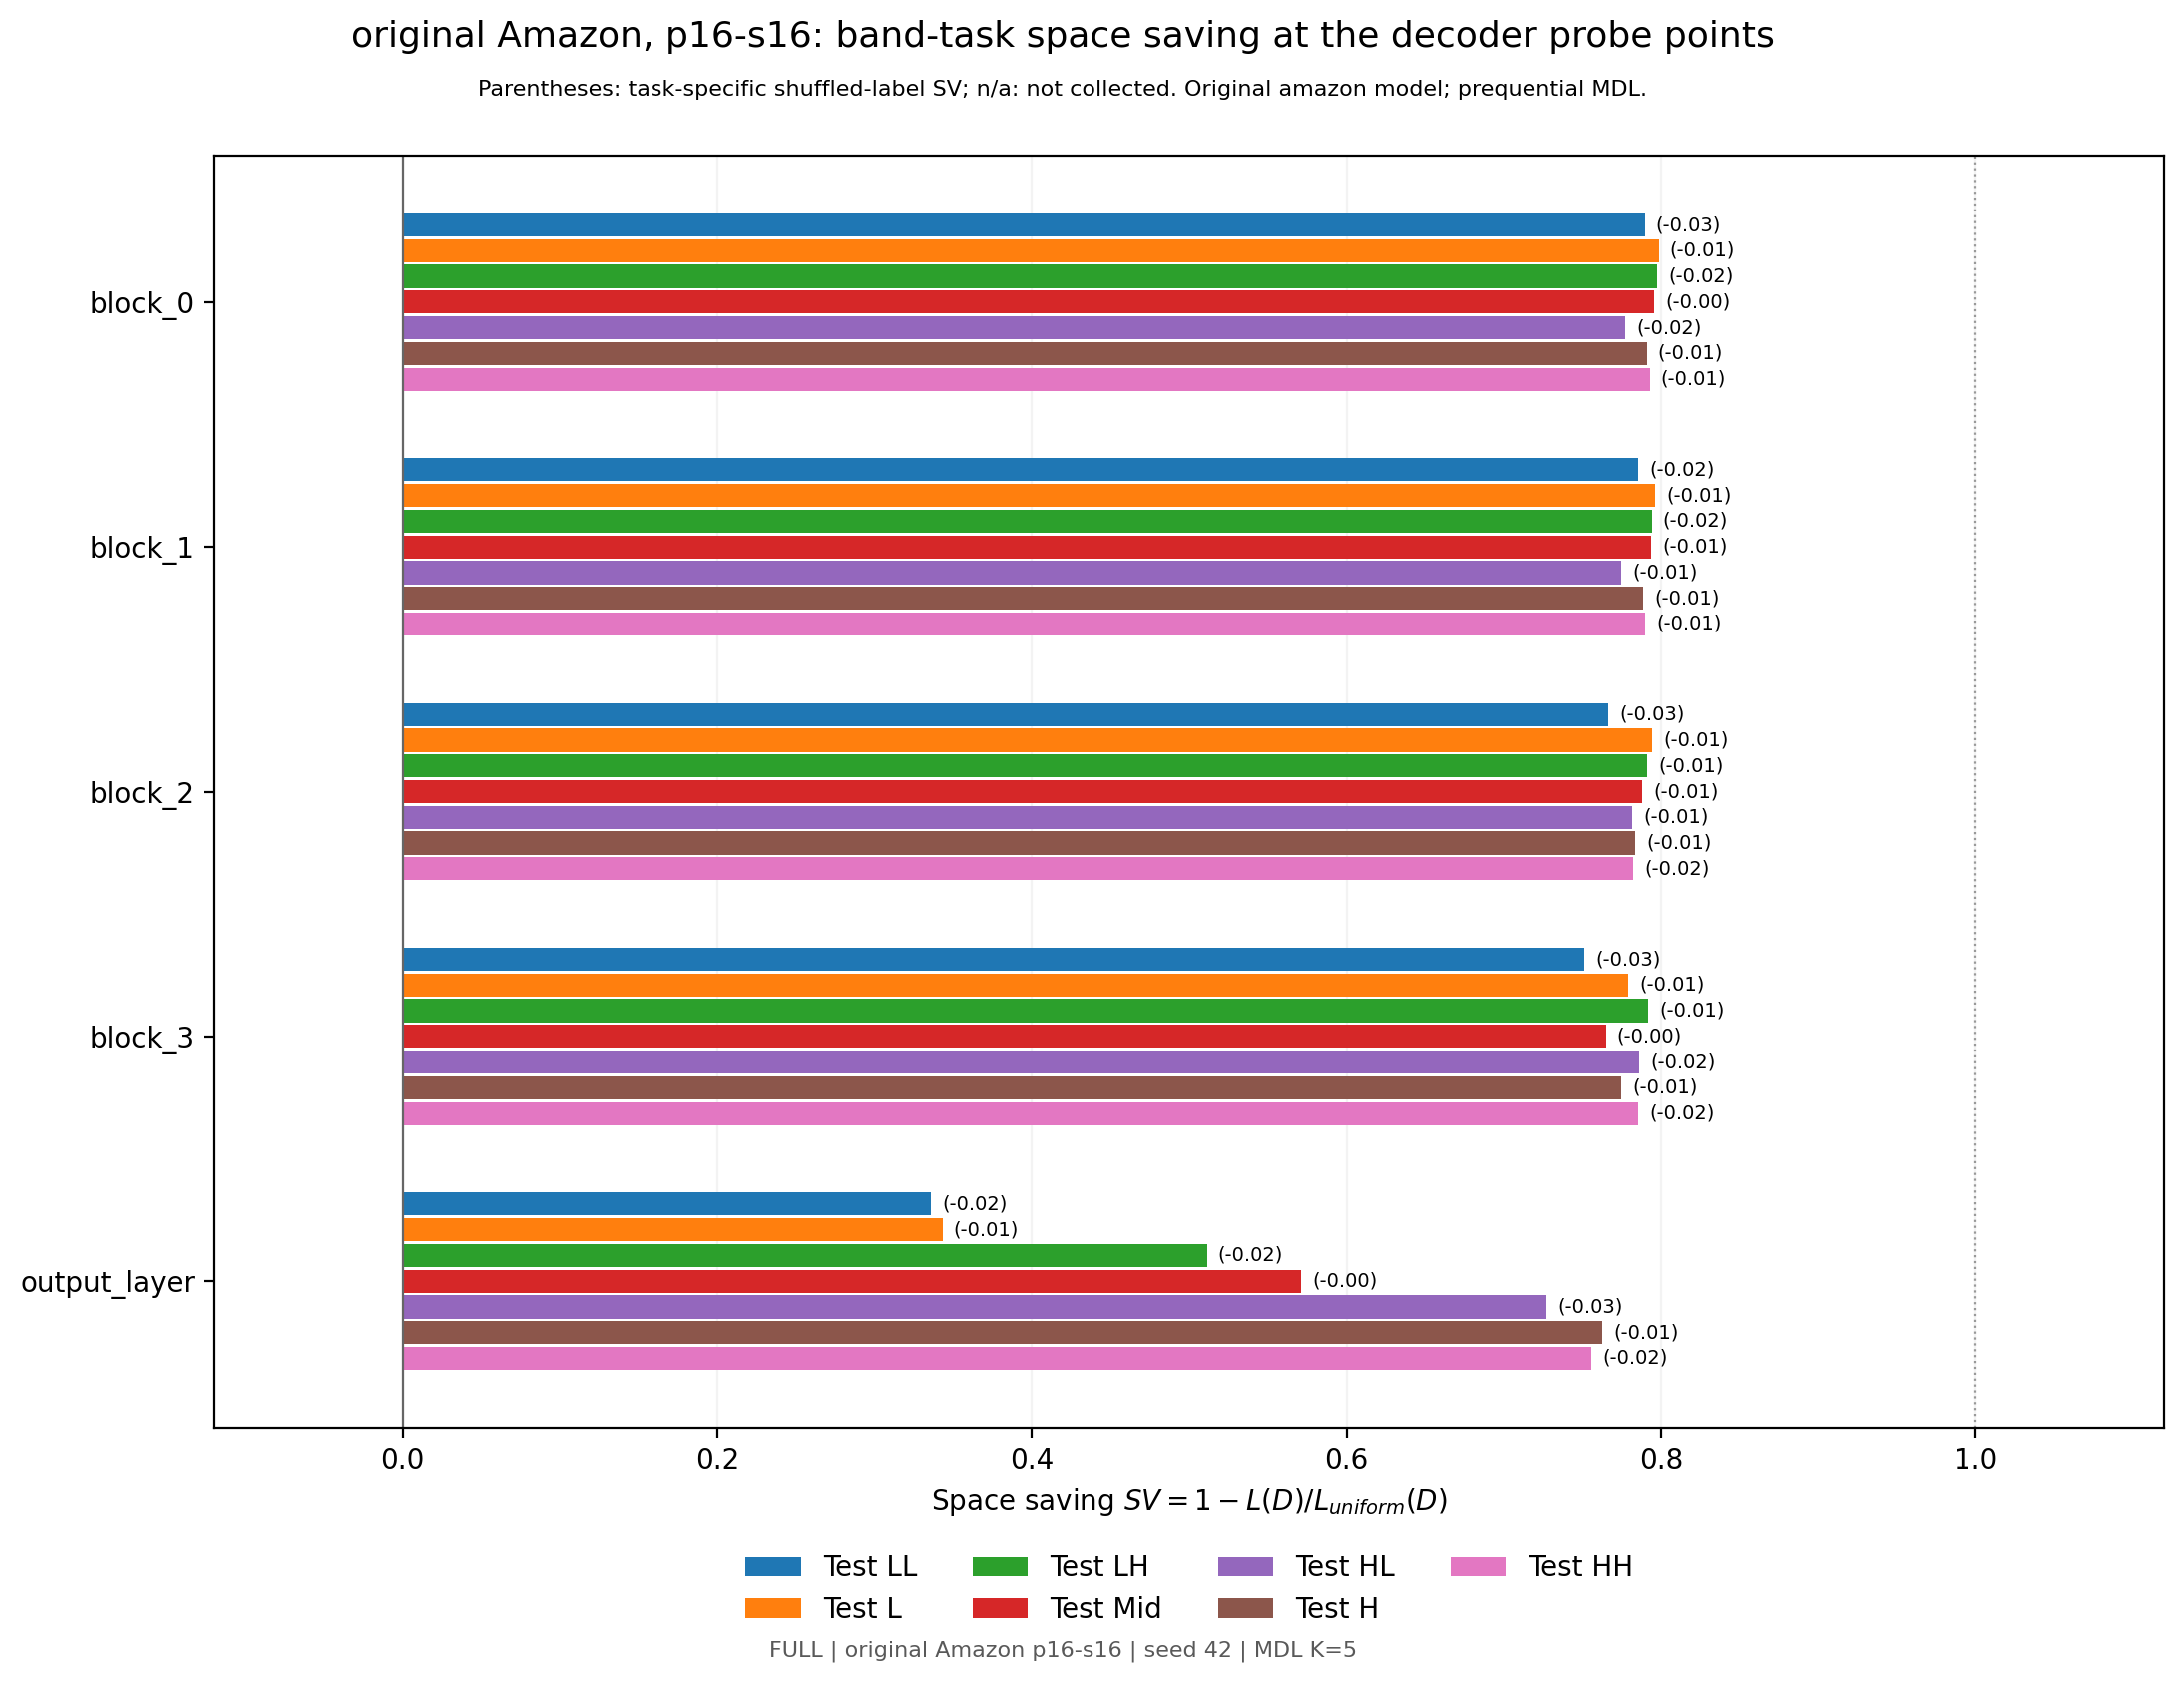

In [7]:
def stage_order(df):
    def key(stage):
        if stage.startswith("enc_"): return (0, int(stage.split("_")[1]))
        if stage.startswith("dec_"): return (1, int(stage.split("_")[1]))
        return (2, ["output_reg", "output_head"].index(stage))
    return sorted(df["stage"].unique(), key=key)


def nice(stage):
    if stage.startswith("enc_"): return f"encoder block {stage.split('_')[1]}"
    if stage.startswith("dec_"): return f"block_{stage.split('_')[1]}"
    return {"output_reg": "pre-projection", "output_head": "output_layer"}[stage]


def complete_grid(table, keys, expected):
    expected_index = pd.MultiIndex.from_product(expected, names=keys)
    indexed = table.set_index(keys)
    missing = expected_index.difference(indexed.index)
    if len(missing):
        raise ValueError(f"Missing measurements for {keys}: {list(missing[:12])}. "
                         "Choose a complete table; missing values are not filled or averaged.")
    return indexed.reindex(expected_index)


def report(path):
    print(f"wrote {path} ({path.stat().st_size / 1024:.0f} kB)")


def save_figure(fig, name):
    path = OUT / "figures" / name
    fig.savefig(path, dpi=200, bbox_inches="tight")
    fig.savefig(path.with_suffix(".pdf"), bbox_inches="tight")
    plt.close(fig)
    report(path); report(path.with_suffix(".pdf"))
    return path

def spacesaving_page(geometry=GEOMETRY, fname=None):
    d = BT[BT["model"] == geometry]
    if d.empty:
        raise ValueError(f"{geometry} not in the table; available: {sorted(BT['model'].unique())}")
    grid = complete_grid(d, ["stage", "task"], [PAPER_STAGES, TASK_ORDER])
    colours = plt.get_cmap("tab10").colors[:len(TASK_ORDER)]
    fig, ax = plt.subplots(figsize=(11.5, 8.5))
    height = 0.105
    ys = np.arange(len(PAPER_STAGES))
    for i, (task, colour) in enumerate(zip(TASK_ORDER, colours)):
        sub = grid.xs(task, level="task").reindex(PAPER_STAGES)
        pos = ys + (i - (len(TASK_ORDER) - 1) / 2) * height
        ax.barh(pos, sub["SV"], height=height * 0.9, color=colour, label=f"Test {task}")
        for y, (_, row) in zip(pos, sub.iterrows()):
            control = row.get("SV_shuffled", np.nan)
            text = f"({control:+.3f})" if pd.notna(control) else "(n/a)"
            ax.annotate(text, (row["SV"], y), xytext=(4 if row["SV"] >= 0 else -4, 0),
                        textcoords="offset points", ha="left" if row["SV"] >= 0 else "right",
                        va="center", fontsize=7)
    values = grid["SV"].to_numpy()
    ax.set_xlim(min(0, values.min()) - 0.12, max(1, values.max()) + 0.12)
    ax.axvline(0, color="0.4", lw=0.8)
    ax.axvline(1.0, color="red", ls="--", lw=1.4)
    ax.set_yticks(ys, [nice(s) for s in PAPER_STAGES])
    ax.invert_yaxis()
    ax.set_xlabel(r"Space saving $SV = 1 - L(D)/L_{uniform}(D)$")
    ax.grid(axis="x", alpha=0.15); ax.set_axisbelow(True)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
    fig.suptitle(f"{MODEL_LABEL}, {geometry}: band-task space saving at the decoder probe points", fontsize=13, y=0.98)
    fig.text(0.5, 0.935, "Bars: true-label SV. Parentheses: shuffled-label SV (3 decimals). "
             f"{MODEL_LABEL.capitalize()} model; prequential MDL.", ha="center", fontsize=8)
    fig.text(0.5, 0.015, SOURCE_NOTE, ha="center", fontsize=8, color="0.35")
    fig.subplots_adjust(left=0.13, right=0.98, top=0.90, bottom=0.15)
    return save_figure(fig, fname or f"FIG_SV_{MODEL_SOURCE}_{geometry}.png")


page = spacesaving_page()
display(Image(filename=str(page)))


## 6. Saved results

The CSV and figure are outputs of the model/MDL run above. They are not prerequisites.


In [8]:
piv = BT.pivot(index="stage", columns="task", values="SV").reindex(index=PAPER_STAGES, columns=TASK_ORDER)
piv.to_csv(OUT / "space_saving.csv")
MANIFEST["status"] = "complete"
MANIFEST["figure"] = str(page)
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")
display(piv.round(3))
print("Finished:", OUT)
for file in sorted(OUT.rglob("*")):
    if file.is_file():
        print(f"  {file.relative_to(OUT)} ({file.stat().st_size / 1024:.0f} kB)")


task,LL,L,LH,Mid,HL,H,HH
stage,,,,,,,
dec_0,0.790,0.799,0.798,0.795,0.777,0.791,0.793
dec_1,0.785,0.796,0.794,0.794,0.775,0.789,0.790
dec_2,0.767,0.794,0.791,0.788,0.782,0.784,0.782
dec_3,0.751,0.779,0.792,0.765,0.786,0.775,0.786
output_head,0.336,0.343,0.511,0.571,0.727,0.763,0.756


Finished: c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260907T225513660729Z
  02_mdl_bandtasks.csv (5 kB)
  figures\FIG_SV_published_p16-s16.pdf (26 kB)
  figures\FIG_SV_published_p16-s16.png (142 kB)
  mdl_coding_chunks.csv (12 kB)
  predictions_and_states.npz (47030 kB)
  run_config.json (2 kB)
  space_saving.csv (1 kB)
  space_saving_partial.csv (5 kB)
